In [3]:
pip install datasets transformers trl peft huggingface_hub dotenv

Note: you may need to restart the kernel to use updated packages.


# 01 — Legal Summarization Dataset Exploration

This notebook profiles the Zenodo legal case summarization archive (`IN-Abs`, `IN-Ext`, and `UK-Abs`) directly from the ZIP file. It validates the archive structure, builds case and judgment–summary manifests, measures document lengths and compression ratios, checks missing pairs and split leakage, analyzes IN-Ext expert/segment coverage, and exports reproducible EDA reports.

**Important:** the archive is not extracted permanently. The notebook reads text members directly with `zipfile`.

## 1. Configuration

The default path below is your dataset path. You can override it with the `LEGAL_DATASET_ZIP` environment variable without editing the notebook.

In [4]:
from pathlib import Path
import os

ZIP_PATH = Path(os.getenv(
    "LEGAL_DATASET_ZIP",
    "/data2/user_data/sg57092c/LLM_finetune/dataset/dataset/legal_dataset.zip",
)).expanduser()

PROJECT_ROOT = ZIP_PATH.parents[2]
REPORT_DIR = Path(os.getenv(
    "LEGAL_EDA_REPORT_DIR",
    str(PROJECT_ROOT / "artifacts" / "eda"),
))
REPORT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
EXPECTED_DATASETS = {"IN-Abs", "IN-Ext", "UK-Abs"}
CONTEXT_WINDOW = 4096

print(f"ZIP_PATH   : {ZIP_PATH}")
print(f"REPORT_DIR : {REPORT_DIR}")

ZIP_PATH   : /data2/user_data/sg57092c/LLM_finetune/dataset/dataset/legal_dataset.zip
REPORT_DIR : /data2/user_data/sg57092c/LLM_finetune/artifacts/eda


## 2. Imports and archive validation

In [5]:
import hashlib
import json
import re
import sys
import zipfile
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", 100)
sns.set_theme(style="whitegrid")
np.random.seed(RANDOM_SEED)

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"Dataset ZIP was not found: {ZIP_PATH}")
if not zipfile.is_zipfile(ZIP_PATH):
    raise ValueError(f"The configured file is not a valid ZIP archive: {ZIP_PATH}")

with zipfile.ZipFile(ZIP_PATH) as zf:
    bad_members = zf.testzip()
    zip_members = [name for name in zf.namelist() if not name.endswith("/")]

if bad_members is not None:
    raise zipfile.BadZipFile(f"CRC validation failed for: {bad_members}")

print(f"Python version : {sys.version.split()[0]}")
print(f"Archive size   : {ZIP_PATH.stat().st_size / 1024**2:,.2f} MiB")
print(f"Files in ZIP   : {len(zip_members):,}")
print("CRC validation : passed")

Python version : 3.12.3
Archive size   : 93.29 MiB
Files in ZIP   : 16,776
CRC validation : passed


## 3. Build an archive manifest

In [6]:
def classify_member(member_name):
    parts = tuple(part for part in member_name.replace("\\", "/").split("/") if part)
    dataset = next((part for part in parts if part in EXPECTED_DATASETS), None)

    if "train-data" in parts:
        split = "train"
    elif "test-data" in parts:
        split = "test"
    elif dataset == "IN-Ext":
        split = "expert_eval"
    else:
        split = "unknown"

    if "summary" in parts:
        record_type = "summary"
    elif "judgement" in parts:
        record_type = "judgment"
    else:
        record_type = "metadata_or_other"

    if record_type == "summary":
        summary_kind = "segment-wise" if "segment-wise" in parts else "full"
    else:
        summary_kind = None

    author = next((part for part in parts if part in {"A1", "A2"}), None)
    segment = None
    if "segment-wise" in parts:
        idx = parts.index("segment-wise")
        candidates = [p for p in parts[idx + 1:-1] if p not in {"A1", "A2", "full"}]
        segment = candidates[-1] if candidates else None

    return {
        "member_name": member_name,
        "dataset": dataset,
        "split": split,
        "record_type": record_type,
        "summary_kind": summary_kind,
        "author": author,
        "segment": segment,
        "filename": parts[-1] if parts else None,
        "extension": Path(parts[-1]).suffix.lower() if parts else None,
    }

manifest_df = pd.DataFrame(classify_member(name) for name in zip_members)
text_manifest_df = manifest_df[
    manifest_df["dataset"].notna() & manifest_df["extension"].eq(".txt")
].copy()

found_datasets = set(text_manifest_df["dataset"].dropna().unique())
missing_datasets = EXPECTED_DATASETS - found_datasets
if missing_datasets:
    print(f"WARNING: expected datasets not found: {sorted(missing_datasets)}")

display(text_manifest_df.head())
display(pd.crosstab(
    [text_manifest_df["dataset"], text_manifest_df["split"]],
    [text_manifest_df["record_type"], text_manifest_df["summary_kind"]],
    dropna=False,
))

,member_name,dataset,split,record_type,summary_kind,author,segment,filename,extension
0,dataset/IN-Abs/test-data/judgement/1181.txt,IN-Abs,test,judgment,NaN,NaN,NaN,1181.txt,.txt
1,dataset/IN-Abs/test-data/judgement/1195.txt,IN-Abs,test,judgment,NaN,NaN,NaN,1195.txt,.txt
2,dataset/IN-Abs/test-data/judgement/1329.txt,IN-Abs,test,judgment,NaN,NaN,NaN,1329.txt,.txt
3,dataset/IN-Abs/test-data/judgement/1378.txt,IN-Abs,test,judgment,NaN,NaN,NaN,1378.txt,.txt
4,dataset/IN-Abs/test-data/judgement/1406.txt,IN-Abs,test,judgment,NaN,NaN,NaN,1406.txt,.txt


record_type         judgment                    metadata_or_other  \
summary_kind            full segment-wise   nan              full   
dataset split                                                       
IN-Abs  expert_eval        0            0     0                 0   
        test               0            0   100                 0   
        train              0            0  7030                 0   
IN-Ext  expert_eval        0            0    50                 0   
        test               0            0     0                 0   
        train              0            0     0                 0   
UK-Abs  expert_eval        0            0     0                 0   
        test               0            0   100                 0   
        train              0            0   693                 0   

record_type                          summary                   
summary_kind        segment-wise nan    full segment-wise nan  
dataset split                                                  
IN-Abs  expert_eval            0   0       0            0   0  
        test                   0   1     100            0   0  
        train                  0   1    7030            0   0  
IN-Ext  expert_eval            0   1     100          474   0  
        test                   0   0       0            0   0  
        train                  0   0       0            0   0  
UK-Abs  expert_eval            0   0       0            0   0  
        test                   0   1     100          300   0  
        train                  0   1     693            0   0

## 4. Read text safely and build case/pair tables

`case_df` contains one row per unique judgment. `pair_df` contains one row per usable full judgment–summary pair, so one IN-Ext case can produce separate A1 and A2 pairs.

In [7]:
WORD_PATTERN = re.compile(r"\b\w+(?:[-'’]\w+)*\b", flags=re.UNICODE)
SENTENCE_PATTERN = re.compile(r"(?<=[.!?])\s+")

def decode_bytes(raw):
    for encoding in ("utf-8", "utf-8-sig", "cp1252", "latin-1"):
        try:
            return raw.decode(encoding), encoding
        except UnicodeDecodeError:
            continue
    return raw.decode("utf-8", errors="replace"), "utf-8-replacement"

def normalize_text(text):
    text = text.replace("\x00", " ")
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    return text.strip()

def text_stats(text):
    words = WORD_PATTERN.findall(text)
    sentences = [s for s in SENTENCE_PATTERN.split(text) if s.strip()]
    return {
        "characters": len(text),
        "words": len(words),
        "sentences": len(sentences),
        "approx_tokens": int(round(len(words) * 1.30)),
    }

def normalized_sha256(text):
    canonical = re.sub(r"\s+", " ", text).strip().lower()
    return hashlib.sha256(canonical.encode("utf-8")).hexdigest()

full_summary_manifest = text_manifest_df[
    text_manifest_df["record_type"].eq("summary")
    & text_manifest_df["summary_kind"].eq("full")
].copy()
judgment_manifest = text_manifest_df[text_manifest_df["record_type"].eq("judgment")].copy()

summary_lookup = {}
for row in full_summary_manifest.itertuples(index=False):
    key = (row.dataset, row.split, row.filename)
    summary_lookup.setdefault(key, []).append(row)

case_rows = []
pair_rows = []
encoding_counter = Counter()

with zipfile.ZipFile(ZIP_PATH) as zf:
    for judgment_row in judgment_manifest.itertuples(index=False):
        judgment_raw = zf.read(judgment_row.member_name)
        judgment_text, judgment_encoding = decode_bytes(judgment_raw)
        judgment_text = normalize_text(judgment_text)
        encoding_counter[judgment_encoding] += 1
        judgment_stats = text_stats(judgment_text)
        case_id = Path(judgment_row.filename).stem
        summaries = summary_lookup.get(
            (judgment_row.dataset, judgment_row.split, judgment_row.filename), []
        )

        case_rows.append({
            "case_id": case_id,
            "dataset": judgment_row.dataset,
            "split": judgment_row.split,
            "filename": judgment_row.filename,
            "judgment_member": judgment_row.member_name,
            "judgment_encoding": judgment_encoding,
            "judgment_hash": normalized_sha256(judgment_text),
            "summary_count": len(summaries),
            **{f"judgment_{k}": v for k, v in judgment_stats.items()},
        })

        for summary_row in summaries:
            summary_raw = zf.read(summary_row.member_name)
            summary_text, summary_encoding = decode_bytes(summary_raw)
            summary_text = normalize_text(summary_text)
            encoding_counter[summary_encoding] += 1
            summary_stats = text_stats(summary_text)
            pair_rows.append({
                "pair_id": f"{judgment_row.dataset}:{judgment_row.split}:{case_id}:{summary_row.author or 'reference'}",
                "case_id": case_id,
                "dataset": judgment_row.dataset,
                "split": judgment_row.split,
                "author": summary_row.author or "reference",
                "judgment_member": judgment_row.member_name,
                "summary_member": summary_row.member_name,
                "judgment_hash": normalized_sha256(judgment_text),
                "summary_hash": normalized_sha256(summary_text),
                **{f"judgment_{k}": v for k, v in judgment_stats.items()},
                **{f"summary_{k}": v for k, v in summary_stats.items()},
                "compression_ratio_words": (
                    summary_stats["words"] / judgment_stats["words"]
                    if judgment_stats["words"] else np.nan
                ),
                "combined_approx_tokens": judgment_stats["approx_tokens"] + summary_stats["approx_tokens"],
            })

case_df = pd.DataFrame(case_rows)
pair_df = pd.DataFrame(pair_rows)

print(f"Unique judgment records : {len(case_df):,}")
print(f"Full training/eval pairs: {len(pair_df):,}")
print(f"Cases without summaries : {(case_df['summary_count'] == 0).sum():,}")
print(f"Detected encodings       : {dict(encoding_counter)}")
display(case_df.groupby(["dataset", "split"], dropna=False).size().rename("unique_judgments").to_frame())
display(pair_df.groupby(["dataset", "split", "author"], dropna=False).size().rename("pairs").to_frame())

Unique judgment records : 7,973
Full training/eval pairs: 8,023
Cases without summaries : 0
Detected encodings       : {'utf-8': 15996}


unique_judgments
dataset split                        
IN-Abs  test                      100
        train                    7030
IN-Ext  expert_eval                50
UK-Abs  test                      100
        train                     693

pairs
dataset split       author       
IN-Abs  test        NaN       100
        train       NaN      7030
IN-Ext  expert_eval A1         50
                    A2         50
UK-Abs  test        NaN       100
        train       NaN       693

## 5. Length and compression statistics

In [8]:
length_summary = (
    pair_df.groupby(["dataset", "split"], dropna=False)
    .agg(
        pairs=("pair_id", "count"),
        median_judgment_words=("judgment_words", "median"),
        mean_judgment_words=("judgment_words", "mean"),
        p95_judgment_words=("judgment_words", lambda s: s.quantile(0.95)),
        median_summary_words=("summary_words", "median"),
        mean_summary_words=("summary_words", "mean"),
        mean_compression_ratio=("compression_ratio_words", "mean"),
        over_4k_context=("combined_approx_tokens", lambda s: int((s > CONTEXT_WINDOW).sum())),
    )
    .round(3)
)
display(length_summary)

context_summary = (
    pair_df.assign(over_context=pair_df["combined_approx_tokens"] > CONTEXT_WINDOW)
    .groupby("dataset")
    .agg(pairs=("pair_id", "count"), over_context=("over_context", "sum"))
)
context_summary["over_context_pct"] = (100 * context_summary["over_context"] / context_summary["pairs"]).round(2)
display(context_summary)
print("Note: approx_tokens uses 1.30 × word count. Use the optional tokenizer section for exact Llama token counts.")

pairs  median_judgment_words  mean_judgment_words  \
dataset split                                                            
IN-Abs  test           100                 3180.0             4802.990   
        train         7030                 3146.5             4386.955   
IN-Ext  expert_eval    100                 4760.0             5386.620   
UK-Abs  test           100                 9267.0            12881.250   
        train          693                10863.0            14551.670   

                     p95_judgment_words  median_summary_words  \
dataset split                                                   
IN-Abs  test                   13920.10                 596.5   
        train                  11332.25                 641.5   
IN-Ext  expert_eval            10693.00                1438.5   
UK-Abs  test                   33736.35                1072.5   
        train                  36291.00                1097.0   

                     mean_summary_words  mean_compression_ratio  \
dataset split                                                     
IN-Abs  test                    937.130                   0.221   
        train                   843.786                   0.234   
IN-Ext  expert_eval            1616.310                   0.308   
UK-Abs  test                   1103.270                   0.128   
        train                  1104.664                   0.111   

                     over_4k_context  
dataset split                         
IN-Abs  test                      62  
        train                   4397  
IN-Ext  expert_eval              100  
UK-Abs  test                      99  
        train                    688

,pairs,over_context,over_context_pct
dataset,,,
IN-Abs,7130,4459,62.54
IN-Ext,100,100,100.00
UK-Abs,793,787,99.24


Note: approx_tokens uses 1.30 × word count. Use the optional tokenizer section for exact Llama token counts.


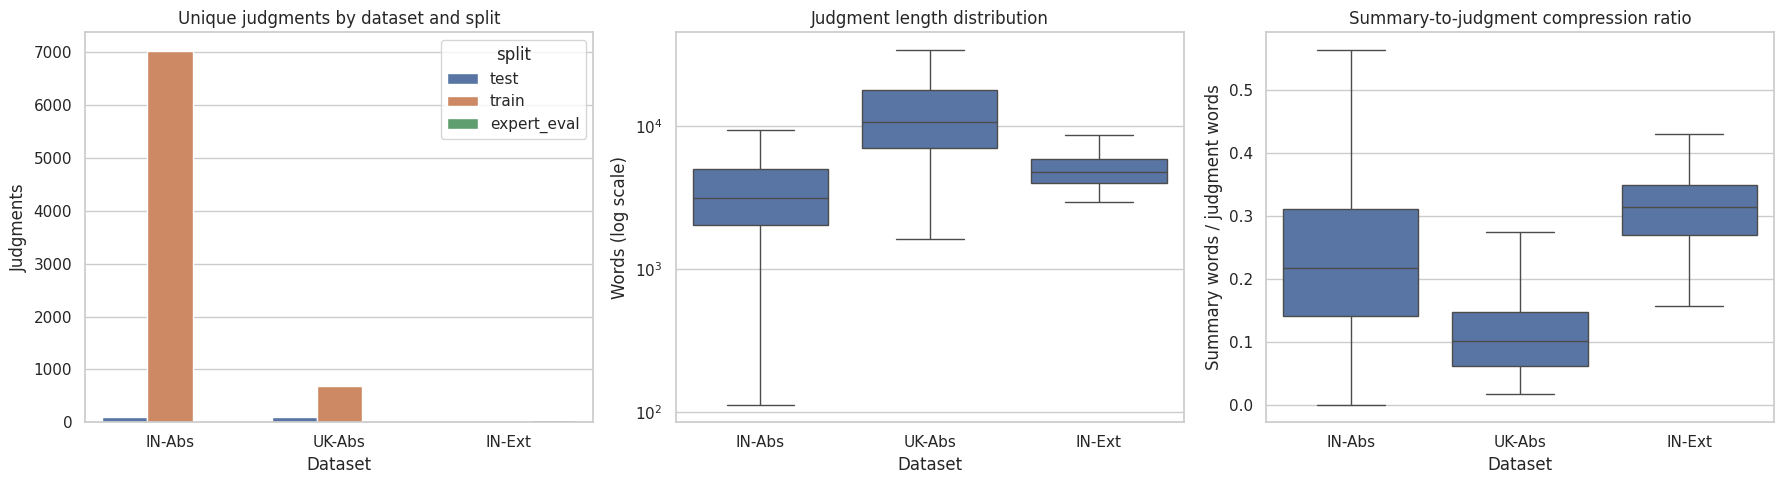

Saved figure: /data2/user_data/sg57092c/LLM_finetune/artifacts/eda/dataset_overview.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=case_df, x="dataset", hue="split", ax=axes[0])
axes[0].set_title("Unique judgments by dataset and split")
axes[0].set_xlabel("Dataset")
axes[0].set_ylabel("Judgments")

sns.boxplot(data=pair_df, x="dataset", y="judgment_words", showfliers=False, ax=axes[1])
axes[1].set_yscale("log")
axes[1].set_title("Judgment length distribution")
axes[1].set_xlabel("Dataset")
axes[1].set_ylabel("Words (log scale)")

sns.boxplot(data=pair_df, x="dataset", y="compression_ratio_words", showfliers=False, ax=axes[2])
axes[2].set_title("Summary-to-judgment compression ratio")
axes[2].set_xlabel("Dataset")
axes[2].set_ylabel("Summary words / judgment words")

plt.tight_layout()
figure_path = REPORT_DIR / "dataset_overview.png"
fig.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved figure: {figure_path}")

## 6. Pairing, duplicate and split-leakage checks

Judgment hashes are checked at the unique-case level. This prevents IN-Ext's A1/A2 references from being incorrectly flagged as duplicate judgments.

In [10]:
missing_summary_df = case_df[case_df["summary_count"].eq(0)].copy()
duplicate_cases_df = case_df[
    case_df.duplicated(["dataset", "judgment_hash"], keep=False)
].sort_values(["dataset", "judgment_hash", "split"])

split_leakage_df = (
    case_df.groupby(["dataset", "judgment_hash"])
    .agg(
        split_count=("split", "nunique"),
        splits=("split", lambda s: sorted(set(s))),
        case_ids=("case_id", lambda s: sorted(set(s))),
    )
    .reset_index()
)
split_leakage_df = split_leakage_df[split_leakage_df["split_count"] > 1]

duplicate_summaries_df = pair_df[
    pair_df.duplicated(["dataset", "summary_hash"], keep=False)
].sort_values(["dataset", "summary_hash"])

quality_checks = pd.DataFrame({
    "check": [
        "Unique judgments",
        "Usable full summary pairs",
        "Judgments missing a full summary",
        "Duplicate judgment rows within dataset",
        "Judgments appearing across splits",
        "Pairs involved in duplicate summaries",
    ],
    "value": [
        len(case_df),
        len(pair_df),
        len(missing_summary_df),
        len(duplicate_cases_df),
        len(split_leakage_df),
        len(duplicate_summaries_df),
    ],
})
display(quality_checks)

if not split_leakage_df.empty:
    print("WARNING: potential train/test leakage detected. Inspect before training.")
    display(split_leakage_df.head(20))

,check,value
0,Unique judgments,7973
1,Usable full summary pairs,8023
2,Judgments missing a full summary,0
3,Duplicate judgment rows within dataset,159
4,Judgments appearing across splits,9
5,Pairs involved in duplicate summaries,180


,dataset,judgment_hash,split_count,splits,case_ids
7164,UK-Abs,049b8cf6bedbc5822a7c52c966157c93f80dd27ce2520c44ce02fa6e9e17ec6d,2,"[test, train]","[uksc-2011-0022, uksc-2011-0024]"
7170,UK-Abs,06485f7050ee52096d18ee5930a6bb1802815adae5cadc96483ed8321096b867,2,"[test, train]","[uksc-2011-0089, uksc-2011-0091]"
7186,UK-Abs,0ada8c2554db1807e5507a79095239149c23944886a018d9a61c648b728c340c,2,"[test, train]","[uksc-2012-0007, uksc-2012-0017]"
7436,UK-Abs,63a0a4b699a6048a474ef51b506ec697ae42c57bf63e9b2694255ca3d2f2faa5,2,"[test, train]","[uksc-2011-0259, uksc-2011-0260, uksc-2011-0261]"
7470,UK-Abs,6d834ef33c6c3672ee3820c2f628f51f47fd51bff65a33e1be1b2f1573e0e12e,2,"[test, train]","[uksc-2010-0106, uksc-2010-0108]"
7676,UK-Abs,b2ab1cb838c3f368af7838586310b7ef33c4d9fc2f7ff7718b21146ea8e16f94,2,"[test, train]","[uksc-2012-0247, uksc-2012-0248]"
7735,UK-Abs,c903dad3ca6ef5c2a5e61ca70b969b894990df0053800d4b2d1cc3395b100943,2,"[test, train]","[uksc-2012-0249, uksc-2012-0259]"
7769,UK-Abs,d4164fa6c7ca96fb7c586f71d46044013a12ecb71868690824ba07936ccd22e4,2,"[test, train]","[uksc-2013-0023, uksc-2013-0024, uksc-2013-0025]"
7838,UK-Abs,ed071cf78298bd37c242cbd8c8c4531af8432c57f6da78cece969135e5905436,2,"[test, train]","[uksc-2011-0011, uksc-2012-0020]"


## 7. IN-Ext expert and segment coverage

In [11]:
in_ext_segments = text_manifest_df[
    text_manifest_df["dataset"].eq("IN-Ext")
    & text_manifest_df["record_type"].eq("summary")
    & text_manifest_df["summary_kind"].eq("segment-wise")
].copy()

if in_ext_segments.empty:
    print("No IN-Ext segment-wise files were found.")
else:
    segment_coverage = pd.crosstab(in_ext_segments["segment"], in_ext_segments["author"])
    display(segment_coverage)

    segment_matrix = (
        in_ext_segments.assign(case_id=in_ext_segments["filename"].map(lambda x: Path(x).stem))
        .pivot_table(index="case_id", columns=["author", "segment"], values="member_name", aggfunc="count", fill_value=0)
    )
    incomplete_segment_cases = segment_matrix[(segment_matrix == 0).any(axis=1)]
    print(f"IN-Ext cases with at least one missing expert segment: {len(incomplete_segment_cases)}")
    if not incomplete_segment_cases.empty:
        display(incomplete_segment_cases.head(20))

author,A1,A2
segment,,
analysis,50,50
argument,46,46
facts,50,50
judgement,50,50
statute,41,41


IN-Ext cases with at least one missing expert segment: 11


author            A1                                        A2                 \
segment     analysis argument facts judgement statute analysis argument facts   
case_id                                                                         
1953_L_1           1        1     1         1       0        1        1     1   
1953_S_23          1        1     1         1       0        1        1     1   
1954_M_25          1        1     1         1       0        1        1     1   
1989_A_55          1        0     1         1       0        1        0     1   
2001_A_234         1        1     1         1       0        1        1     1   
2001_S_1131        1        1     1         1       0        1        1     1   
2008_I_54          1        0     1         1       1        1        0     1   
2010_S_431         1        0     1         1       1        1        0     1   
2012_S_270         1        0     1         1       0        1        0     1   
2014_J_33          1        1     1         1       0        1        1     1   
2015_J_10          1        1     1         1       0        1        1     1   

author                         
segment     judgement statute  
case_id                        
1953_L_1            1       0  
1953_S_23           1       0  
1954_M_25           1       0  
1989_A_55           1       0  
2001_A_234          1       0  
2001_S_1131         1       0  
2008_I_54           1       1  
2010_S_431          1       1  
2012_S_270          1       0  
2014_J_33           1       0  
2015_J_10           1       0

## 8. Optional exact Llama tokenizer analysis

Set `RUN_EXACT_TOKEN_ANALYSIS = True` after installing `transformers` and obtaining access to the gated Llama 2 tokenizer. This section samples unique cases by default to avoid unnecessarily slow analysis.

In [12]:
from huggingface_hub import login
from dotenv import load_dotenv
import os

load_dotenv()

hf_token = os.getenv("HF_TOKEN")

if hf_token is None:
    raise ValueError("HF_TOKEN was not found in the .env file")

login(token=hf_token)
print("Hugging Face login successful")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Hugging Face login successful


In [13]:
RUN_EXACT_TOKEN_ANALYSIS = True
TOKENIZER_NAME = "meta-llama/Llama-2-7b-hf"
TOKEN_SAMPLE_SIZE = min(1000, len(case_df))

if RUN_EXACT_TOKEN_ANALYSIS:
    from transformers import AutoTokenizer

    tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME, use_fast=True)
    sampled_cases = case_df.sample(TOKEN_SAMPLE_SIZE, random_state=RANDOM_SEED).copy()

    exact_counts = []
    with zipfile.ZipFile(ZIP_PATH) as zf:
        for row in sampled_cases.itertuples(index=False):
            text, _ = decode_bytes(zf.read(row.judgment_member))
            token_count = len(tokenizer(normalize_text(text), add_special_tokens=False)["input_ids"])
            exact_counts.append(token_count)

    sampled_cases["exact_judgment_tokens"] = exact_counts
    display(sampled_cases.groupby("dataset")["exact_judgment_tokens"].describe().round(2))
    print(f"Share over {CONTEXT_WINDOW} tokens: {(sampled_cases['exact_judgment_tokens'] > CONTEXT_WINDOW).mean():.2%}")
else:
    print("Exact tokenizer analysis skipped. Set RUN_EXACT_TOKEN_ANALYSIS=True to enable it.")

config.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

,count,mean,std,min,25%,50%,75%,max
dataset,,,,,,,,
IN-Abs,890.0,6272.61,7483.46,383.0,2967.25,4481.0,6808.25,121647.0
IN-Ext,6.0,7207.50,1081.37,5887.0,6400.75,7187.5,7915.75,8686.0
UK-Abs,104.0,20971.36,17349.12,3329.0,9390.25,15495.5,24961.75,94856.0


Share over 4096 tokens: 60.70%


## 9. Inspect a reproducible sample

Only short previews are printed to avoid exposing entire judgments in notebook outputs.

In [14]:
if pair_df.empty:
    print("No complete judgment–summary pairs are available for inspection.")
else:
    sample_row = pair_df.sample(1, random_state=RANDOM_SEED).iloc[0]
    with zipfile.ZipFile(ZIP_PATH) as zf:
        judgment_preview, _ = decode_bytes(zf.read(sample_row["judgment_member"]))
        summary_preview, _ = decode_bytes(zf.read(sample_row["summary_member"]))

    print(f"Pair ID : {sample_row['pair_id']}")
    print(f"Dataset : {sample_row['dataset']} | Split: {sample_row['split']} | Author: {sample_row['author']}")
    print("\nJUDGMENT PREVIEW\n", normalize_text(judgment_preview)[:1000], "...")
    print("\nSUMMARY PREVIEW\n", normalize_text(summary_preview)[:700], "...")

Pair ID : IN-Abs:train:1834:nan
Dataset : IN-Abs | Split: train | Author: nan

JUDGMENT PREVIEW
 minal Appeals Nos.
30 34 of 1964.
Appeals by special leave from the judgment and order dated October 22, 1963 of the Allahabad High Court in Criminal Appeals Nos. 77 and 78 of 1963.
M. section K. Sastri, for the appellant (in Cr. A. No. 30 of 1964).
I. M. Lall and Ganpat Rai, for the appellants (in Cr. A. No. 31 of 1964).
V. 'Y. Sawhney, for the appellants (in Cr. A. Nos.
32 34/64).
0. P. Rana, Atiqur Pehman and C. P. Lal, for the res pondents May, 4.
The Judgment of the Court delivered by GAJENDRAGADKAR, C. J. Forty person were charged with having committed several offences the principal one of which was under section 302 read with section 149 of the Indian Penal Code.
The case against these persons was tried by the first Additional Sessions judge at Jhansi.
The other charges framed against them were under section 307 / 149, 201/ 149 & SI 1, 395, 396, 149 & 449, 1.
The learned trial Judge 

## 10. Export EDA artifacts

In [15]:
case_df.to_csv(REPORT_DIR / "case_manifest.csv", index=False)
pair_df.to_csv(REPORT_DIR / "full_summary_pair_manifest.csv", index=False)
text_manifest_df.to_csv(REPORT_DIR / "archive_manifest.csv", index=False)
length_summary.to_csv(REPORT_DIR / "length_summary.csv")
quality_checks.to_csv(REPORT_DIR / "quality_checks.csv", index=False)
split_leakage_df.to_csv(REPORT_DIR / "potential_split_leakage.csv", index=False)

eda_summary = {
    "zip_path": str(ZIP_PATH),
    "archive_size_mib": round(ZIP_PATH.stat().st_size / 1024**2, 2),
    "archive_file_count": len(zip_members),
    "datasets_found": sorted(found_datasets),
    "unique_judgments": int(len(case_df)),
    "full_summary_pairs": int(len(pair_df)),
    "missing_full_summaries": int(len(missing_summary_df)),
    "potential_split_leakage_groups": int(len(split_leakage_df)),
    "context_window_for_estimate": CONTEXT_WINDOW,
}
with open(REPORT_DIR / "eda_summary.json", "w", encoding="utf-8") as f:
    json.dump(eda_summary, f, indent=2)

print("EDA artifacts written to:", REPORT_DIR)
for output_path in sorted(REPORT_DIR.iterdir()):
    print(" -", output_path.name)

EDA artifacts written to: /data2/user_data/sg57092c/LLM_finetune/artifacts/eda
 - archive_manifest.csv
 - case_manifest.csv
 - dataset_overview.png
 - eda_summary.json
 - full_summary_pair_manifest.csv
 - length_summary.csv
 - potential_split_leakage.csv
 - quality_checks.csv


## 11. Decisions before preprocessing and training

After reviewing the generated tables, use the following policy in `02_data_validation_and_splitting.ipynb`:

1. Use the official IN-Abs training set as the primary Indian-domain data source.
2. Create a case-level validation split only from the official training partition.
3. Keep the official IN-Abs test set untouched.
4. Keep IN-Ext for expert-reference and segment-coverage evaluation; do not count A1/A2 as different cases.
5. Treat UK-Abs as a separate jurisdictional experiment or tag jurisdiction explicitly if training a shared model.
6. Resolve every missing pair, duplicate, and cross-split hash before training.
7. Use structure-aware chunking or extract-then-abstract preprocessing for records exceeding the model context window.
8. Calculate exact token lengths with the final training tokenizer before producing SFT records.